### Household Structured Epidemic Model - Vectorized Structure
Here we use a transmission rule that allows transmission to differ based on whether people have some shared trait to create an epidemic model with household structure. Here folks are far more likely to transmit to others in their household, and move through the standard S, I and R states once infected.

In [1]:
import numpy as np
import pandas as pd

from tabularepimdl.SimpleTransition_Vec_Encode import SimpleTransition_Vec_Encode
from tabularepimdl.SimpleInfection_Vec_Encode import SimpleInfection_Vec_Encode
from tabularepimdl.SharedTraitInfection_Vec_Encode import SharedTraitInfection_Vec_Encode

from tabularepimdl.EpiModel_Vec_Encode1_2 import EpiModel_Vec_Encode_1_2

%matplotlib inline
import matplotlib.pyplot as plt
import plotly.express as px


### Defining a Population
The population is going to consist of 500 households with a mean size of 2. We will add an infected person to the last household on the list (HH number 499).

In [2]:
np.random.seed(3) #make sure every time the random function generates the same numbers

infstate_compartments = ['S', 'I', 'R']
column_compartments =  ['S', 'I', 'R']
trait_col_all_categories = list(range(500))

hh_pop = pd.DataFrame({
    'InfState':["S"]*500+["I"],
    'HH_Number': list(range(500))+[499],
    'N': list(np.random.poisson(2,500))+[1],
    'T':0
})
hh_pop.tail()

,InfState,HH_Number,N,T
496,S,496,1,0
497,S,497,2,0
498,S,498,4,0
499,S,499,1,0
500,I,499,1,0


### Creating an Epidemic Model

To define the epidemic model we will use a transmission rule that allows us to specify different transmission probabilities for those inside and outside of the household. Here we will assume that those inside the household have a 20% chance of transmitting to a fellow household member, and that they have a 0.2% chance transmitting to someone outside. Given an average household size of 0.2 and a total population of approximately 1000, $R_0$ is approximately:
$$R_0 \approx (0.2)*(2) + (0.002)*(1000) = 2.4$$

We will further presume infection lasts an average of 5 days.

In [3]:
num_of_days = 5
shared_trait_rule_vec = SharedTraitInfection_Vec_Encode(inf_col='InfState', in_beta=0.2/num_of_days, out_beta=0.002/num_of_days, trait_col='HH_Number', trait_col_all_categories=trait_col_all_categories, infstate_compartments=infstate_compartments)
infect_rule_vec = SimpleInfection_Vec_Encode(beta=2.4/num_of_days, column='InfState', s_st='S', i_st='I', inf_to='I', infstate_compartments=infstate_compartments, column_categories=column_compartments)
recover_rule_vec = SimpleTransition_Vec_Encode(column='InfState', from_st='I', to_st='R', rate=0.2, infstate_compartments=infstate_compartments, column_categories=column_compartments)

In [4]:
hh_mdl_vec = EpiModel_Vec_Encode_1_2(init_state=hh_pop, rules=[shared_trait_rule_vec, recover_rule_vec], compartment_col='InfState')

### Comparison with an unstructured SIR model

How does houehold structure change the shape of the epidemic curve, even if transmission is determinstic? We will need a standard SIR model with an equivalent R0 to compare to.

In [5]:
#First let's get the an equivalent population that does not have the population structure.
simp_pop = hh_pop.copy().drop("HH_Number", axis=1)
simp_pop = simp_pop.groupby(["InfState","T"], observed=False).sum().reset_index()

sir_mdl_vec = EpiModel_Vec_Encode_1_2(init_state = simp_pop ,rules=[infect_rule_vec, recover_rule_vec], compartment_col = 'InfState')

Now that we have both of these models let's run both deterministically and compare results.

In [6]:
for i in range(400):
    hh_mdl_vec.do_timestep(dt=0.25)
    sir_mdl_vec.do_timestep(dt=0.25)

In [7]:
#get the number infected at each time step from the hh_mdl_vec
hh_res = hh_mdl_vec._covnert_list_of_arrays_to_df(hh_mdl_vec._full_epi_list).drop("HH_Number", axis=1)
hh_res = hh_res.groupby(["InfState","T"]).sum().reset_index()
hh_res["mdl"] = "HH"

sir_res = sir_mdl_vec._covnert_list_of_arrays_to_df(sir_mdl_vec._full_epi_list)
sir_res["mdl"] = "SIR"

all_res = pd.concat([hh_res, sir_res])

epi_fig_determ = px.line(all_res, x="T", y="N", color="InfState",line_dash="mdl", title="Household_structured deterministic Epi model vs. simple SIR model")
epi_fig_determ.show()

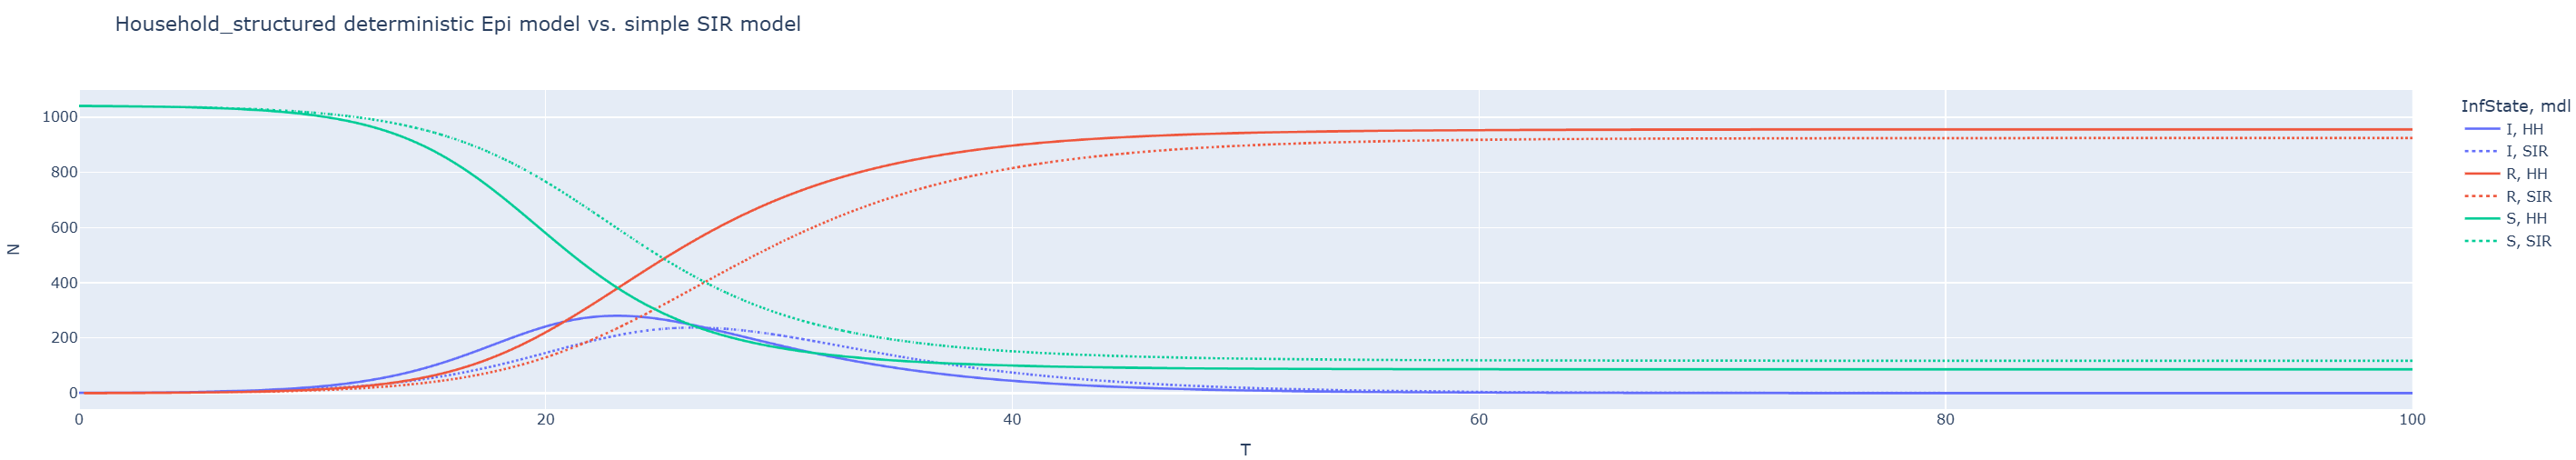

### Comparing Stochastic and Deterministic Results
The household process is actually a bit more intesting from the stochastic prospective. Let's now compare that with the deterministic results, particularly around differences in household attack rates.

In [8]:
## Reset the model and set it to be stochastic
hh_mdl_vec.Reset()
hh_mdl_vec.stoch_policy="stochastic"


np.random.seed(3)

##run an epidemic
for i in range(400):
    hh_mdl_vec.do_timestep(dt=0.25)

Now look at the results of this run, including the epidemic curve compared to the non-stochastic version and the distribution of attack rate.

In [9]:
hh_res_stoch = hh_mdl_vec._covnert_list_of_arrays_to_df(hh_mdl_vec._full_epi_list)
hh_res_stoch = hh_res_stoch.groupby(["InfState","T"]).sum().reset_index()
hh_res_stoch["mdl"] = "HH_STOCH"

all_res = pd.concat([all_res, hh_res_stoch])

epi_fig_stoch = px.line(all_res, x="T", y="N", color="InfState",line_dash="mdl", title="Household_structured stochastic Epi model vs. simple SIR model")
epi_fig_stoch.show()

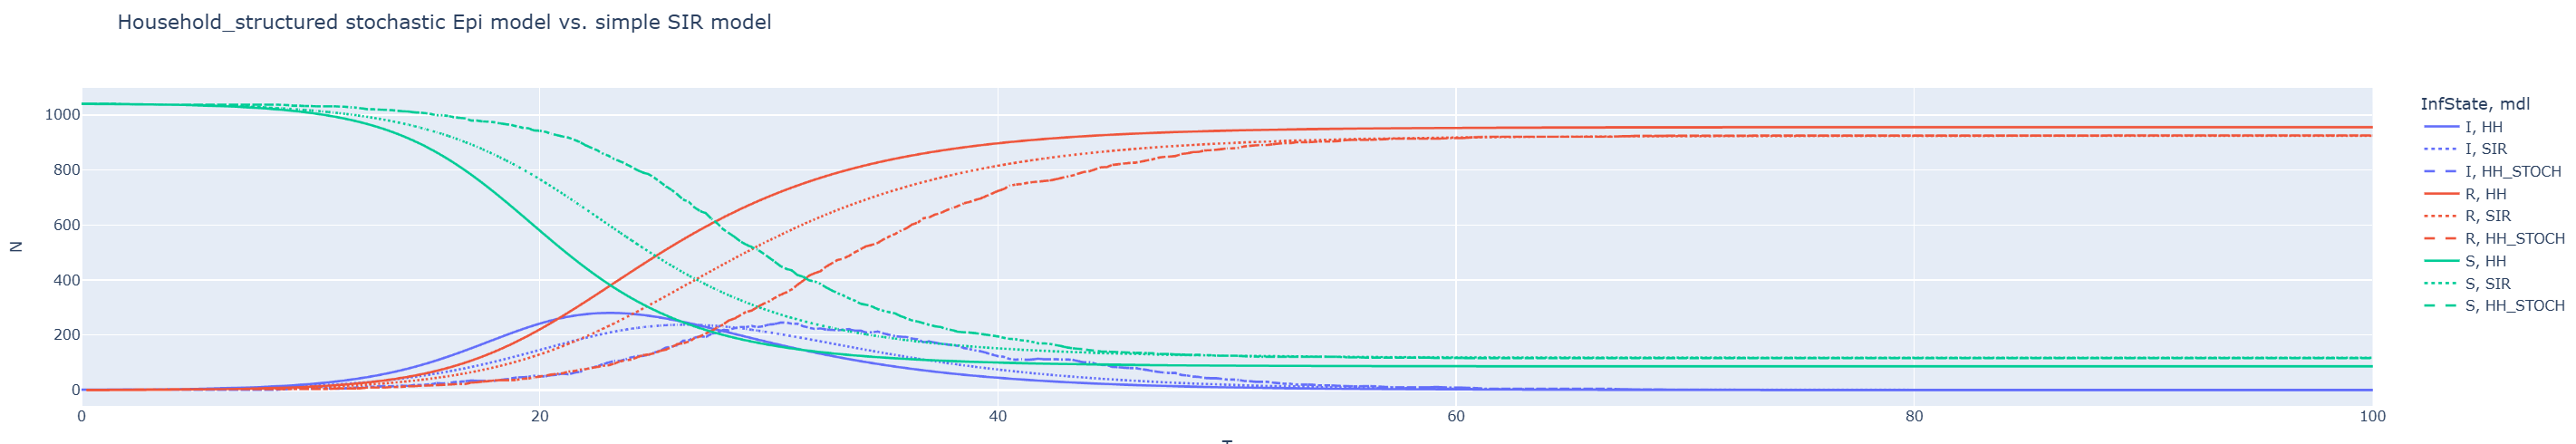